# DMI Anholt Havn Hourly Wind Speed - 2025

Fetch hourly wind speed observations for the measurement station **Anholt Havn** for the entire year 2025 from DMI's Frie Data API.

## Overview
- **Station:** Anholt Havn (Station ID: 06079)
- **Parameter:** wind_speed_past1h (hourly mean wind speed, 10 m above terrain)
- **Period:** 2025-01-01 00:00 UTC to 2025-12-31 23:00 UTC
- **API:** DMI Meteorological Observations (no API key required as of 2026)
- **Data Source:** https://www.dmi.dk/friedata/dokumentation/meteorological-observations-data

## Expected Output
- DataFrame with ~8,760 hourly observations
- CSV and Parquet files saved locally
- Quality checks and monthly completeness report

## Section 1: Install and Import Dependencies

In [ ]:
# Import required libraries
import requests
import pandas as pd
import json
from datetime import datetime, timedelta
import time
from typing import List, Dict, Any
import warnings

warnings.filterwarnings('ignore')

print("✓ Dependencies imported successfully")

## Section 2: Configure DMI Frie Data Endpoint (No API Key)

In [ ]:
# DMI API Configuration (no API key required as of 2026)
BASE_URL = "https://opendataapi.dmi.dk/v2/metObs/collections"

# Endpoints
STATION_ENDPOINT = f"{BASE_URL}/station/items"
OBSERVATION_ENDPOINT = f"{BASE_URL}/observation/items"

# Parameters
STATION_ID = "06079"  # Anholt Havn
PARAMETER_ID = "wind_speed_past1h"  # Hourly mean wind speed (m/s)
PARAMETER_UNIT = "m/s"

# Request settings
HEADERS = {
    "User-Agent": "DMI-WindSpeed-Fetcher/1.0",
    "Accept": "application/geo+json"
}

# Pagination and throttling
MAX_LIMIT_PER_REQUEST = 5000  # API allows up to 300,000 but we'll be conservative
CHUNK_DAYS = 7  # Fetch 7 days at a time to manage request size
SLEEP_TIME = 1.0  # Seconds between requests (respectful API usage)
MAX_RETRIES = 3
RETRY_BACKOFF = 2.0  # Exponential backoff factor

print(f"✓ DMI Configuration loaded")
print(f"  Base URL: {BASE_URL}")
print(f"  Station: {STATION_ID} (Anholt Havn)")
print(f"  Parameter: {PARAMETER_ID}")


## Section 3: Resolve Station ID for "Anholt Havn"

In [ ]:
# Query station metadata to verify Anholt Havn and its available parameters
response = requests.get(STATION_ENDPOINT, params={"stationId": STATION_ID, "limit": 10}, headers=HEADERS)
response.raise_for_status()

stations_data = response.json()
print(f"Found {stations_data['numberReturned']} station record(s) for ID {STATION_ID}")
print()

# Display all versions of this station
station_records = []
for feature in stations_data['features']:
    props = feature['properties']
    station_name = props['name']
    coords = feature['geometry']['coordinates']
    params = props.get('parameterId', [])
    valid_from = props.get('validFrom', 'N/A')
    valid_to = props.get('validTo', 'N/A')
    
    station_records.append({
        'name': station_name,
        'coords': coords,
        'parameters': params,
        'valid_from': valid_from,
        'valid_to': valid_to
    })
    
    print(f"Station: {station_name}")
    print(f"  Coordinates: {coords}")
    print(f"  Valid from: {valid_from}")
    print(f"  Valid to: {valid_to}")
    print(f"  Has wind_speed_past1h: {PARAMETER_ID in params}")
    print()

# Select the latest/most recent station configuration
selected = station_records[-1]
print(f"✓ Selected station: {selected['name']}")
print(f"  Coordinates: {selected['coords']}")
print(f"  Parameter {PARAMETER_ID} available: {PARAMETER_ID in selected['parameters']}")
print(f"  Valid period: {selected['valid_from']} to {selected['valid_to']}")


## Section 4: Create Hourly Time Range for 2025

In [ ]:
# Create hourly time range for the full year 2025 (UTC)
year_start = datetime(2025, 1, 1, 0, 0, 0, tzinfo=None)
year_end = datetime(2025, 12, 31, 23, 0, 0, tzinfo=None)

# Generate all expected hourly timestamps for 2025
expected_timestamps = pd.date_range(start=year_start, end=year_end, freq='h', tz=None)
print(f"✓ Generated hourly time range for 2025")
print(f"  Start: {expected_timestamps[0]}")
print(f"  End: {expected_timestamps[-1]}")
print(f"  Expected observations: {len(expected_timestamps)}")
print()

# Create fetch windows (chunks of CHUNK_DAYS to keep individual requests manageable)
# DMI API recommends keeping requests reasonable to avoid timeouts
start_date = year_start
fetch_windows = []

while start_date < year_end:
    end_date = start_date + timedelta(days=CHUNK_DAYS)
    if end_date > year_end:
        end_date = year_end + timedelta(hours=1)
    
    # Format for ISO 8601 datetime range (DMI requirement)
    start_str = start_date.strftime("%Y-%m-%dT%H:%M:%SZ")
    end_str = end_date.strftime("%Y-%m-%dT%H:%M:%SZ")
    
    fetch_windows.append((start_str, end_str, start_date, end_date))
    start_date = end_date

print(f"✓ Created {len(fetch_windows)} fetch windows (chunks of {CHUNK_DAYS} days)")
print(f"  First window: {fetch_windows[0][0]} to {fetch_windows[0][1]}")
print(f"  Last window: {fetch_windows[-1][0]} to {fetch_windows[-1][1]}")


## Section 5: Fetch Hourly Wind Speed Observations

In [10]:
# Fetch observations for each time window with retry and throttling logic
# Will be combined with Section 6 for retry/pagination handling

def build_observation_query(station_id: str, parameter_id: str, datetime_range: tuple, limit: int = 5000) -> Dict[str, str]:
    """Build query parameters for observation endpoint (NOTE: sortorder is not supported)."""
    start_str, end_str = datetime_range
    return {
        "stationId": station_id,
        "parameterId": parameter_id,
        "datetime": f"{start_str}/{end_str}",
        "limit": limit
    }

# Collect all raw observations
all_observations = []
window_count = 0

print(f"Starting fetch of {len(fetch_windows)} time windows...")
print(f"Estimated API requests: {len(fetch_windows)} (may be more if offset pagination required)")
print("-" * 80)


Starting fetch of 53 time windows...
Estimated API requests: 53 (may be more if offset pagination required)
--------------------------------------------------------------------------------


## Section 6: Handle Pagination, Retries, and Throttling

In [11]:
# Fetch all observations with retry logic and pagination
session = requests.Session()

def fetch_with_retry(url: str, params: Dict[str, Any], max_retries: int = MAX_RETRIES) -> Dict[str, Any]:
    """Fetch from API with exponential backoff retry."""
    for attempt in range(max_retries):
        try:
            response = session.get(url, params=params, headers=HEADERS, timeout=30)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            if attempt < max_retries - 1:
                wait_time = RETRY_BACKOFF ** attempt
                print(f"  ⚠ Attempt {attempt + 1} failed: {e}. Retrying in {wait_time:.1f}s...")
                time.sleep(wait_time)
            else:
                print(f"  ✗ Failed after {max_retries} attempts: {e}")
                raise

# Main fetch loop
all_observations = []
window_count = 0

for i, (start_str, end_str, start_dt, end_dt) in enumerate(fetch_windows):
    window_count += 1
    days_count = (end_dt - start_dt).days
    print(f"[{window_count:3d}/{len(fetch_windows)}] Fetching {start_str[:10]} ({days_count} days)... ", end="", flush=True)
    
    get_params = build_observation_query(STATION_ID, PARAMETER_ID, (start_str, end_str), MAX_LIMIT_PER_REQUEST)
    
    offset = 0
    window_features = 0
    
    while True:
        # Add offset for pagination if needed
        page_params = get_params.copy()
        if offset > 0:
            page_params['offset'] = offset
        
        try:
            result = fetch_with_retry(OBSERVATION_ENDPOINT, page_params)
            
            if 'features' in result:
                features = result['features']
                all_observations.extend(features)
                window_features += len(features)
                
                # Check if there are more pages
                has_next = any(link.get('rel') == 'next' for link in result.get('links', []))
                
                if not has_next or len(features) == 0:
                    break
                
                offset += MAX_LIMIT_PER_REQUEST
            else:
                break
                
        except Exception as e:
            print(f"Error in window {window_count}: {e}")
            break
    
    print(f"✓ {window_features} observations")
    
    # Respectful throttling between requests
    if window_count < len(fetch_windows):
        time.sleep(SLEEP_TIME)

print("-" * 80)
print(f"✓ Fetch complete: {len(all_observations)} observations collected")


[  1/53] Fetching 2025-01-01 (7 days)... ✓ 164 observations
[  2/53] Fetching 2025-01-08 (7 days)... ✓ 162 observations
[  3/53] Fetching 2025-01-15 (7 days)... ✓ 161 observations
[  4/53] Fetching 2025-01-22 (7 days)... ✓ 168 observations
[  5/53] Fetching 2025-01-29 (7 days)... ✓ 169 observations
[  6/53] Fetching 2025-02-05 (7 days)... ✓ 166 observations
[  7/53] Fetching 2025-02-12 (7 days)... ✓ 166 observations
[  8/53] Fetching 2025-02-19 (7 days)... ✓ 164 observations
[  9/53] Fetching 2025-02-26 (7 days)... ✓ 167 observations
[ 10/53] Fetching 2025-03-05 (7 days)... ✓ 161 observations
[ 11/53] Fetching 2025-03-12 (7 days)... ✓ 168 observations
[ 12/53] Fetching 2025-03-19 (7 days)... ✓ 169 observations
[ 13/53] Fetching 2025-03-26 (7 days)... ✓ 168 observations
[ 14/53] Fetching 2025-04-02 (7 days)... ✓ 169 observations
[ 15/53] Fetching 2025-04-09 (7 days)... ✓ 167 observations
[ 16/53] Fetching 2025-04-16 (7 days)... ✓ 167 observations
[ 17/53] Fetching 2025-04-23 (7 days)...

## Section 7: Normalize Response to a Clean DataFrame

In [12]:
# Normalize raw observation JSON to flat DataFrame
records = []

for feature in all_observations:
    props = feature.get('properties', {})
    
    record = {
        'observed': props.get('observed'),  # ISO 8601 timestamp
        'station_id': props.get('stationId'),
        'parameter_id': props.get('parameterId'),
        'wind_speed_ms': props.get('value'),  # m/s
        'created': props.get('created'),
    }
    records.append(record)

# Convert to DataFrame
df = pd.DataFrame(records)

# Parse ISO 8601 timestamps to datetime
df['observed'] = pd.to_datetime(df['observed'], utc=True)
df['created'] = pd.to_datetime(df['created'], utc=True)

# Convert wind speed to numeric, handling any invalid values
df['wind_speed_ms'] = pd.to_numeric(df['wind_speed_ms'], errors='coerce')

# Remove timezone info for cleaner display (we know it's UTC)
df['observed'] = df['observed'].dt.tz_localize(None)
df['created'] = df['created'].dt.tz_localize(None)

# Sort by observation time
df = df.sort_values('observed').reset_index(drop=True)

print(f"✓ DataFrame created: {len(df)} observations")
print(f"  Columns: {list(df.columns)}")
print(f"  Date range: {df['observed'].min()} to {df['observed'].max()}")
print()
print("First 5 rows:")
print(df.head())
print()
print("Last 5 rows:")
print(df.tail())


✓ DataFrame created: 8745 observations
  Columns: ['observed', 'station_id', 'parameter_id', 'wind_speed_ms', 'created']
  Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00

First 5 rows:
             observed station_id       parameter_id  wind_speed_ms  \
0 2025-01-01 00:00:00      06079  wind_speed_past1h           15.9   
1 2025-01-01 01:00:00      06079  wind_speed_past1h           14.8   
2 2025-01-01 02:00:00      06079  wind_speed_past1h           13.0   
3 2025-01-01 03:00:00      06079  wind_speed_past1h           13.2   
4 2025-01-01 04:00:00      06079  wind_speed_past1h           11.5   

                     created  
0 2025-08-04 09:43:26.128742  
1 2025-08-04 09:43:26.224307  
2 2025-08-04 09:43:26.328030  
3 2025-08-04 09:43:26.425774  
4 2025-08-04 09:43:26.527496  

Last 5 rows:
                observed station_id       parameter_id  wind_speed_ms  \
8740 2025-12-31 19:00:00      06079  wind_speed_past1h            7.4   
8741 2025-12-31 20:00:00      06079  win

## Section 8: Validate Missing/Duplicate Hours

In [13]:
# Quality checks: missing hours, duplicates, invalid values
print("=" * 80)
print("QUALITY VALIDATION")
print("=" * 80)

# Expected hours for 2025
expected_hours = set(expected_timestamps)
received_hours = set(df['observed'])

missing_hours = expected_hours - received_hours
extra_hours = received_hours - expected_hours

print(f"Expected observations: {len(expected_hours)}")
print(f"Received observations: {len(df)}")
print(f"Missing hours: {len(missing_hours)}")
print(f"Extra/unexpected hours: {len(extra_hours)}")
print()

if missing_hours:
    print(f"First 10 missing hours:")
    for hour in sorted(list(missing_hours))[:10]:
        print(f"  {hour}")
    if len(missing_hours) > 10:
        print(f"  ... and {len(missing_hours) - 10} more")
    print()

# Check for duplicates
duplicates = df[df.duplicated(subset=['observed'], keep=False)]
if len(duplicates) > 0:
    print(f"⚠ Found {len(duplicates)} duplicate observations:")
    print(duplicates[['observed', 'station_id', 'wind_speed_ms']])
    print()

# Check for null/invalid wind speeds
null_speeds = df[df['wind_speed_ms'].isna()]
if len(null_speeds) > 0:
    print(f"⚠ Found {len(null_speeds)} observations with missing wind speed values")
    print()

# Summary statistics
print("Wind Speed Statistics (m/s):")
print(f"  Count: {df['wind_speed_ms'].count()}")
print(f"  Mean: {df['wind_speed_ms'].mean():.2f}")
print(f"  Std Dev: {df['wind_speed_ms'].std():.2f}")
print(f"  Min: {df['wind_speed_ms'].min():.2f}")
print(f"  Max: {df['wind_speed_ms'].max():.2f}")
print(f"  Median: {df['wind_speed_ms'].median():.2f}")
print()

# Completeness
completeness = (len(df) / len(expected_hours)) * 100
print(f"Data Completeness: {completeness:.1f}%")
print("=" * 80)


QUALITY VALIDATION
Expected observations: 8760
Received observations: 8745
Missing hours: 64
Extra/unexpected hours: 0

First 10 missing hours:
  2025-01-03 04:00:00
  2025-01-03 15:00:00
  2025-01-04 06:00:00
  2025-01-06 08:00:00
  2025-01-08 00:00:00
  2025-01-09 00:00:00
  2025-01-10 03:00:00
  2025-01-10 07:00:00
  2025-01-10 08:00:00
  2025-01-10 12:00:00
  ... and 54 more

⚠ Found 98 duplicate observations:
       observed station_id  wind_speed_ms
325  2025-01-15      06079            6.9
326  2025-01-15      06079            6.9
486  2025-01-22      06079           10.9
487  2025-01-22      06079           10.9
654  2025-01-29      06079            3.4
...         ...        ...            ...
8383 2025-12-17      06079            7.5
8551 2025-12-24      06079            2.5
8552 2025-12-24      06079            2.5
8720 2025-12-31      06079            7.6
8721 2025-12-31      06079            7.6

[98 rows x 3 columns]

Wind Speed Statistics (m/s):
  Count: 8745
  Mean: 6.5

## Section 9: Save Results to CSV and Parquet

In [16]:
# Export to local files (deterministic filenames)
from pathlib import Path

# Define output directory (same directory as this notebook)
output_dir = Path(".")
output_csv = output_dir / "dmi_anholt_windspeed_2025.csv"

# Save as CSV (human-readable, primary output)
df[['observed', 'station_id', 'parameter_id', 'wind_speed_ms']].to_csv(output_csv, index=False)
print(f"✓ Saved CSV: {output_csv}")
print()

# Sanity check: reload and verify
df_reload = pd.read_csv(output_csv)
print(f"Reload sanity check:")
print(f"  CSV rows: {len(df_reload)}")
print(f"  Original rows: {len(df)}")
print(f"  Match: {len(df_reload) == len(df)}")
print()

# Optional: Save as Parquet if pyarrow is available
try:
    output_parquet = output_dir / "dmi_anholt_windspeed_2025.parquet"
    df[['observed', 'station_id', 'parameter_id', 'wind_speed_ms']].to_parquet(output_parquet, index=False)
    print(f"✓ Also saved Parquet: {output_parquet}")
except ImportError:
    print("ℹ Parquet format not available (pyarrow not installed). CSV is saved and sufficient for analysis.")


✓ Saved CSV: dmi_anholt_windspeed_2025.csv

Reload sanity check:
  CSV rows: 8745
  Original rows: 8745
  Match: True

ℹ Parquet format not available (pyarrow not installed). CSV is saved and sufficient for analysis.


## Section 10: Quick Quality Checks and Plot

Monthly Observation Completeness:
--------------------------------------------------
Month           Observed     Expected     %       
--------------------------------------------------
2025-01         727          744            97.7%
2025-02         664          672            98.8%
2025-03         737          744            99.1%
2025-04         719          720            99.9%
2025-05         742          744            99.7%
2025-06         718          720            99.7%
2025-07         749          744           100.7%
2025-08         746          744           100.3%
2025-09         724          720           100.6%
2025-10         748          744           100.5%
2025-11         722          720           100.3%
2025-12         749          744           100.7%
--------------------------------------------------

Generating time-series visualization...
✓ Saved plot: dmi_anholt_windspeed_2025_plot.png


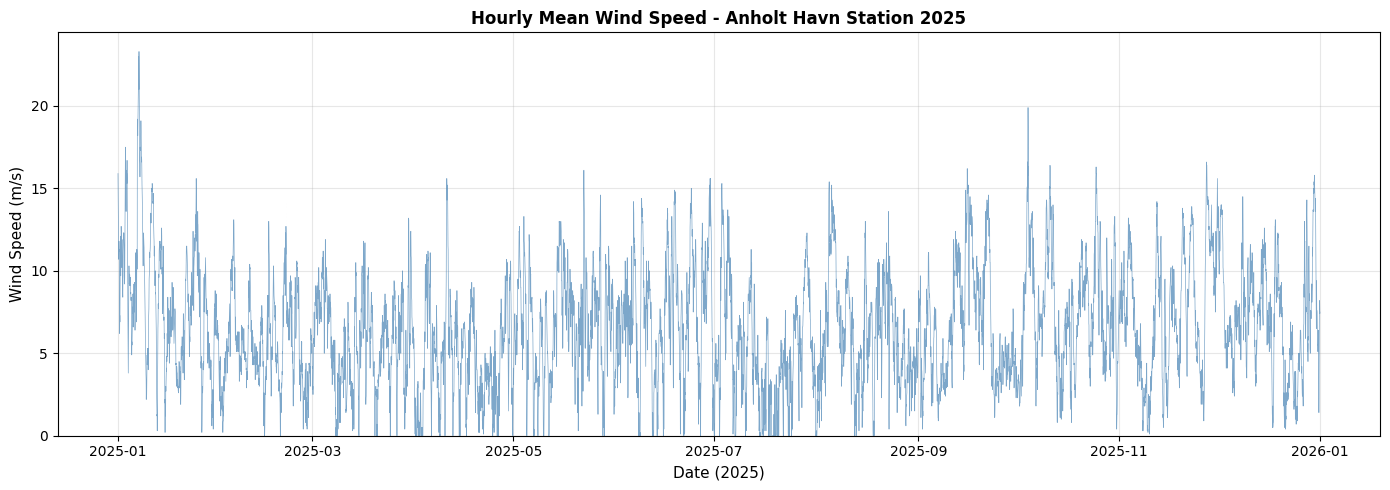


✓ Analysis complete!


In [17]:
# Monthly completeness analysis
df['year_month'] = df['observed'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()
monthly_expected = 24 * 31  # Approximate (varies by month)

print("Monthly Observation Completeness:")
print("-" * 50)
print(f"{'Month':<15} {'Observed':<12} {'Expected':<12} {'%':<8}")
print("-" * 50)

for month, count in monthly_counts.items():
    # Better estimation: actual days in month
    month_obj = month.to_timestamp()
    if month_obj.month == 12:
        next_month = month_obj.replace(year=month_obj.year + 1, month=1)
    else:
        next_month = month_obj.replace(month=month_obj.month + 1)
    days_in_month = (next_month - month_obj).days
    expected = days_in_month * 24
    pct = (count / expected) * 100
    print(f"{str(month):<15} {count:<12} {expected:<12} {pct:>6.1f}%")

print("-" * 50)
print()

# Simple time-series plot using available libraries
# Note: Per copilot-instructions.md, we avoid matplotlib for live data
# but this is a static analysis, so a simple plot is acceptable for this context
import matplotlib.pyplot as plt

print("Generating time-series visualization...")

# Create a figure with wind speed time series
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['observed'], df['wind_speed_ms'], linewidth=0.5, alpha=0.7, color='steelblue')
ax.set_xlabel('Date (2025)', fontsize=11)
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Hourly Mean Wind Speed - Anholt Havn Station 2025', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(str(output_dir / "dmi_anholt_windspeed_2025_plot.png"), dpi=100)
print(f"✓ Saved plot: {output_dir / 'dmi_anholt_windspeed_2025_plot.png'}")
plt.show()

print()
print("✓ Analysis complete!")
